# Michigan-Sentiment-Day — a quantitative teardown 🔬
### A release-day event study · a low-then-rising regime split · the decisive **naive-t vs block-bootstrap** gap · the 21-episode clustering · a buy-the-bottom overlay · robustness · a planted-edge control

![Signal: None on the release-day · Weak on the level](https://img.shields.io/badge/Signal-None_%C2%B7_Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bottom--timer%3F: Not_supported](https://img.shields.io/badge/Bottom--timer%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two believer claims, separated: (A) the sentiment **release** moves SPY and its surprise drifts; (B) a **low-and-rising** sentiment regime marks tradable equity bottoms. We find (A) a **non-event** (release-day *t* ≈ 0, surprise drift the wrong sign) and (B) a textbook **overlapping-return mirage**: a naive Welch *t* of **+3.55** at 12 months that a **circular block bootstrap** (*p* = 0.10) refuses to certify, resting on ~**21 independent episodes**, with the sentiment *level alone* carrying nothing.

> ⚠️ **Data + snapshot note.** FRED's CSV endpoint is firewalled here; sentiment is a hardcoded monthly snapshot of `UMCSENT` (final print, **not** the real-time preliminary vintage — named on the Signal axis). SPY is yfinance daily adjusted close (total-return), daily for the event study and month-end for the regime test. Release days use the second-Friday schedule proxy. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from michigan_sentiment_day import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_monthly() if HAVE_REAL else None
SPY = data.load_spy() if HAVE_REAL else None
DATES = data.release_dates(1993, 2026)
print("SPY cache present:", HAVE_REAL,
      "| sentiment+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-31', 'end': '2026-04-30', 'months': 400, 'years': 33.2, 'daily_days': 8405, 'rel_n': 401, 'rel_mean_bp': 6.2, 'all_mean_bp': 4.8, 'rel_t': 0.23, 'drift1': (196, 8.2, 204, 17.1, -0.64), 'drift2': (196, 23.4, 204, 43.7, -1.31), 'h1': (1, 0.95, 1.02, 0.19, 1.55, 70, 1.01, 0.09), 'h3': (3, 2.81, 2.85, 0.05, 3.73, 68, 0.85, 0.261), 'h6': (6, 5.77, 5.41, -0.33, 8.21, 67, 1.54, 0.203), 'h12': (12, 11.97, 11.55, -0.25, 18.65, 64, 3.55, 0.103), 'episodes': 21, 'overlay': (11.3, 0.77, 3.3, 0.46, 3.1, 0.44, 53, 18), 'robust': [('q<=20%', 47, 18.6, 3.08, 0.159), ('q<=30%', 64, 18.7, 3.55, 0.103), ('q<=40%', 89, 16.0, 2.3, 0.187), ('k=1', 75, 15.1, 1.51, 0.274), ('k=6', 66, 18.2, 3.9, 0.111), ('ex-GFC', 64, 18.1, 3.63, 0.115), ('ex-COVID', 59, 17.0, 2.37, 0.237)], 'syn': [(0.0, 29, 1.67, 1.73, -0.02, 0.332), (0.1, 29, 61.23, 13.0, 8.35, 0.004)]}


SPY cache present: True | sentiment+SPY months: 400


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` on release-day · `WEAK` on level | Release day **+6.2 bp** vs all-day **+4.8 bp** (*t* = +0.23); 12m low-and-rising **+18.6%** vs base **+12.0%** — naive *t* = **+3.55** but block-boot **p = 0.10**, level-alone *t* = -0.25. |
| **Tradability** | `MIRAGE` | Buy-the-bottom overlay **+3.1%/yr** (Sharpe **0.44**, exposure **18%**) vs buy-hold **+11.3%/yr** (Sharpe **0.77**). |
| **Bottom-timer?** | `NOT SUPPORTED` | 64 signal months = ~**21 independent episodes**; the effect is 'significant' only through the one statistic that ignores the overlap. |

> 💡 In plain words: a low-that's-rising in sentiment happens almost only *after* a crash, when equities are cheap and rebounding. The 12-month forward return then looks huge — but it's the same ~20 recoveries measured through overlapping windows, which inflates the naive *t*. Respect the overlap and the certainty evaporates.

## 1 · The claim, steelmanned

Let $s_t$ be the Michigan sentiment level. Two hypotheses:

- **A — release-day drift.** The release-day SPY return exceeds an ordinary day, and the next-day drift is positive after a *beat* ($\Delta s_t = s_t - s_{t-1} > 0$).
- **B — bottom-timer.** Let $p_t$ = the expanding percentile rank of $s_t$ (no look-ahead). **LOW** = $p_t \le 0.30$; **RISING** = $s_t > s_{t-3}$. The believers claim $\mathbb{E}[r_{t\to t+H}\mid \text{LOW\&RISING}] > \mathbb{E}[r_{t\to t+H}]$ — a *positive* excess, strongest at long $H$.

We find **A rejected** (release-day *t* ≈ 0; surprise drift the wrong sign), **B directionally true but uncertifiable**: the naive Welch *t* is large only at the long, overlapping horizon where it's least trustworthy, and a block bootstrap can't clear it. The contrarian instinct is right where it's untradable (own equities after crashes) and unproven where it would pay (a certifiable, tradable bottom signal).

## 2 · So what? — what rides on each answer

The regime test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{LR}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{LR}}/k + s^2_{\text{all}}/N\,}}.$$

The trap: at $H=12$ the forward returns are **12-month overlapping** windows, so both the LR set and the base are heavily autocorrelated and the naive *t* **over-rejects** (Richardson–Stock 1989; Boudoukh–Richardson–Whitelaw 2008). The honest inference resamples the forward-return series in **circular blocks** (Politis–Romano 1994) of length 12 and asks how often chance matches $\widehat{\Delta}$. If $k=64$ signal months are really $\sim\!21$ independent episodes, the effective sample is tiny and the block-boot $p$ tells the truth the naive $t$ hides.

## 3 · How we'd know — the protocol

- **Sentiment tape.** Monthly `UMCSENT` (index, 1966:Q1=100), hardcoded snapshot, 1993-01→2026-04 (400 months). Final print, not real-time vintage (named on the axis).
- **Release-day event study.** Second-Friday release proxy; release-day SPY return vs all-day mean (Welch *t*); next-day drift split by $\text{sign}(\Delta s_t)$, entered at the release-day close (print already public — no look-ahead).
- **Regime.** $p_t$ = expanding percentile (≥36-mo warmup); LOW = $p_t\le0.30$, RISING = $s_t>s_{t-3}$; forward $H\in\{1,3,6,12\}$-month returns entered at month-end after the mid-month print (no extra lag).
- **Null #1 (Welch t).** LR-set mean vs the unconditional mean.
- **Null #2 (block bootstrap).** Circular 12-month-block resample of the forward-return series; $p = \Pr[\text{block-boot excess} \ge \widehat{\Delta}]$ — the autocorrelation-aware test.
- **Clustering.** Independent-episode count (signal months > 2 months apart).
- **Tradability.** Buy-the-bottom overlay, 1-month lag, 10 bps one-way per switch, excess-of-zero Sharpe (labelled), vs buy-and-hold.
- **Positive control.** A deterministic series with a *planted* low-then-rising→forward link over the next 12 months: `edge=0` must not fake significance; a large `edge` must light up the *t* **and** the block bootstrap.

## 4 · The teardown

### 4a · Release day is a non-event

Release-day mean SPY return vs the all-day mean, and the next-day drift split by the surprise sign. A tradable announcement drift needs the *beat* bar above the *miss* bar.

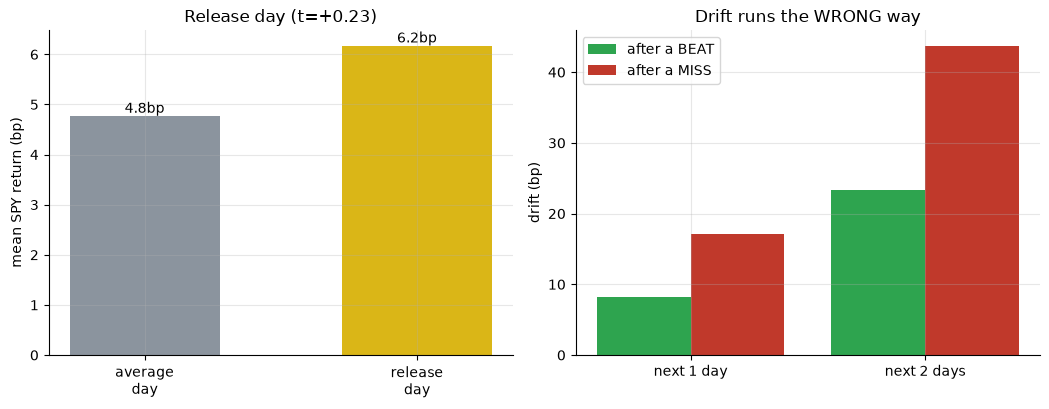

release t=+0.23; drift 1d beat-miss t=-0.64; 2d t=-1.31


In [2]:
if HAVE_REAL:
    rd = st.release_day_summary(SPY, DATES)
    d1 = st.drift_by_surprise(SPY, data.sentiment_series(), DATES, lag=1)
    d2 = st.drift_by_surprise(SPY, data.sentiment_series(), DATES, lag=2)
    rel_bp, all_bp, tv = rd['release_mean']*1e4, rd['all_mean']*1e4, rd['t_vs_all']
    b1,m1,t1 = d1['beat_mean']*1e4, d1['miss_mean']*1e4, d1['t_beat_minus_miss']
    b2,m2,t2 = d2['beat_mean']*1e4, d2['miss_mean']*1e4, d2['t_beat_minus_miss']
else:
    rel_bp, all_bp, tv = R['rel_mean_bp'], R['all_mean_bp'], R['rel_t']
    b1,m1,t1 = R['drift1'][1], R['drift1'][3], R['drift1'][4]
    b2,m2,t2 = R['drift2'][1], R['drift2'][3], R['drift2'][4]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(['average\nday','release\nday'], [all_bp, rel_bp], color=[GREY, AMBER], width=.55)
for i,v in enumerate([all_bp, rel_bp]): a1.annotate(f'{v:.1f}bp',(i,v),ha='center',va='bottom')
a1.set_ylabel('mean SPY return (bp)'); a1.set_title(f'Release day (t={tv:+.2f})')
x = np.arange(2)
a2.bar(x-.2, [b1,b2], .4, color=GREEN, label='after a BEAT')
a2.bar(x+.2, [m1,m2], .4, color=RED, label='after a MISS')
a2.set_xticks(x); a2.set_xticklabels(['next 1 day','next 2 days'])
a2.set_ylabel('drift (bp)'); a2.set_title('Drift runs the WRONG way'); a2.legend()
plt.tight_layout(); plt.show()
print(f'release t={tv:+.2f}; drift 1d beat-miss t={t1:+.2f}; 2d t={t2:+.2f}')

> 💡 In plain words: release day is **+6.2 bp** vs **+4.8 bp** normally (*t* = +0.23) — statistically a normal day. And the surprise drift is *negative*: bigger after misses than beats (1-day *t* = -0.64, 2-day *t* = -1.31). **Hypothesis A rejected** — there is no release-day edge, in level or in surprise direction.

### 4b · The regime split — the level is dead, the combo *looks* alive

Forward means for **LOW** (level only) and **LOW&RISING**, vs the base rate, with $\pm$SE. LOW alone hugs the base at every horizon; LOW&RISING pulls away — but read the *t* against what produces it.

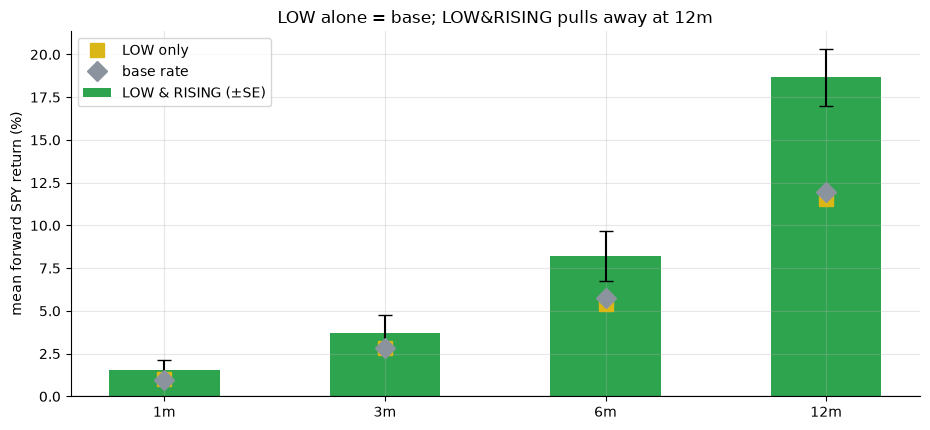

naive Welch t (low&rising) by horizon: {'1m': 1.01, '3m': 0.85, '6m': 1.54, '12m': 3.55}


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    lrm, lom, bm, tlr, ses = [], [], [], [], []
    for m in hs:
        s = st.summarize_regime(F, m, boot=False)
        lrm.append(s['low_rising_mean']); lom.append(s['low_mean']); bm.append(s['base_mean']); tlr.append(s['t_low_rising'])
        fwd = st.forward_returns(F, m); mask = st.regime_mask(F)['low_rising']
        v = fwd[mask & fwd.notna()].dropna().values; ses.append(v.std(ddof=1)/np.sqrt(len(v)))
else:
    lrm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    lom = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][1]/100, R['h3'][1]/100, R['h6'][1]/100, R['h12'][1]/100]
    tlr = [R['h1'][6], R['h3'][6], R['h6'][6], R['h12'][6]]; ses=[.02,.035,.05,.055]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x, [v*100 for v in lrm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='LOW & RISING (±SE)')
ax.plot(x, [v*100 for v in lom], 's', ms=10, c=AMBER, label='LOW only')
ax.plot(x, [v*100 for v in bm], 'D', ms=10, c=GREY, label='base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('LOW alone = base; LOW&RISING pulls away at 12m'); ax.legend()
plt.tight_layout(); plt.show()
print('naive Welch t (low&rising) by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,tlr)})

> 💡 In plain words: the sentiment **level alone is inert** — LOW months return **+11.6%** at 12m vs base **+12.0%** (*t* = -0.25). Cheap sentiment does *not* mean higher returns. Only the LOW-**and**-RISING combo separates (**+18.6%**, naive *t* = **+3.55**) — and that's exactly the 'buy after the bounce has started' set. The next chart asks whether that *t* means anything.

### 4c · The decisive test — naive *t* vs block bootstrap

For each horizon, the naive Welch *t* (which ignores the overlap) next to the autocorrelation-aware **block-bootstrap p** (12-month block). A real edge clears **both**; an overlapping-return artefact clears only the naive *t*.

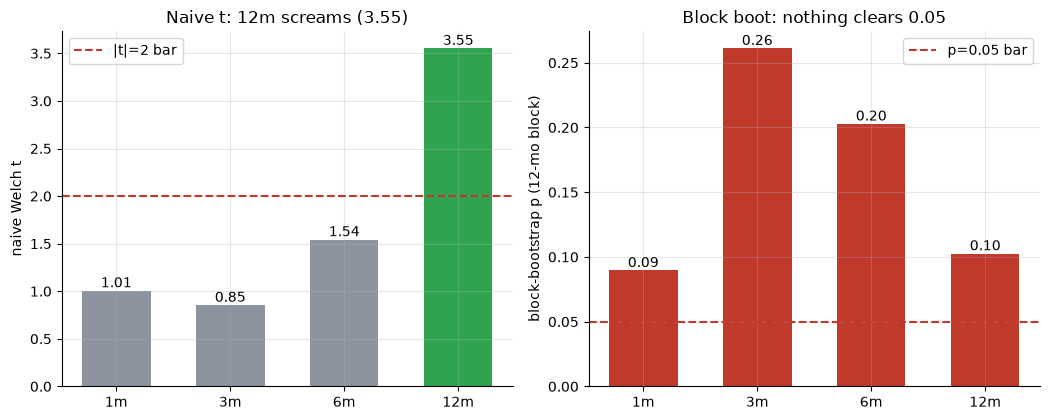

12m: naive t = 3.55 | block-boot p = 0.103


In [4]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    tt, pp = [], []
    for m in hs:
        s = st.summarize_regime(F, m); tt.append(s['t_low_rising']); pp.append(s['p_block'])
else:
    tt = [R['h1'][6], R['h3'][6], R['h6'][6], R['h12'][6]]
    pp = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([f'{m}m' for m in hs], tt, color=[GREEN if t>=2 else GREY for t in tt], width=.6)
a1.axhline(2, ls='--', c=RED, label='|t|=2 bar')
for i,t in enumerate(tt): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom')
a1.set_ylabel('naive Welch t'); a1.set_title('Naive t: 12m screams (3.55)'); a1.legend()
a2.bar([f'{m}m' for m in hs], pp, color=[GREEN if p<.05 else RED for p in pp], width=.6)
a2.axhline(.05, ls='--', c=RED, label='p=0.05 bar')
for i,p in enumerate(pp): a2.annotate(f'{p:.2f}',(i,p),ha='center',va='bottom')
a2.set_ylabel('block-bootstrap p (12-mo block)'); a2.set_title('Block boot: nothing clears 0.05'); a2.legend()
plt.tight_layout(); plt.show()
print('12m: naive t =', round(tt[-1],2), '| block-boot p =', round(pp[-1],3))

> 💡 In plain words: at 12 months the naive *t* is **+3.55** (looks decisive) but the block-bootstrap *p* is **0.10** — *not* significant. The gap between the two panels **is** the finding: the apparent signal lives entirely in the autocorrelation the naive *t* pretends isn't there. This is the load-bearing result.

### 4d · Why — the signal is ~21 episodes, not 64 draws

The signal months plotted on the sentiment tape. The naive *t* treats them as independent; they are a handful of post-crash recoveries.

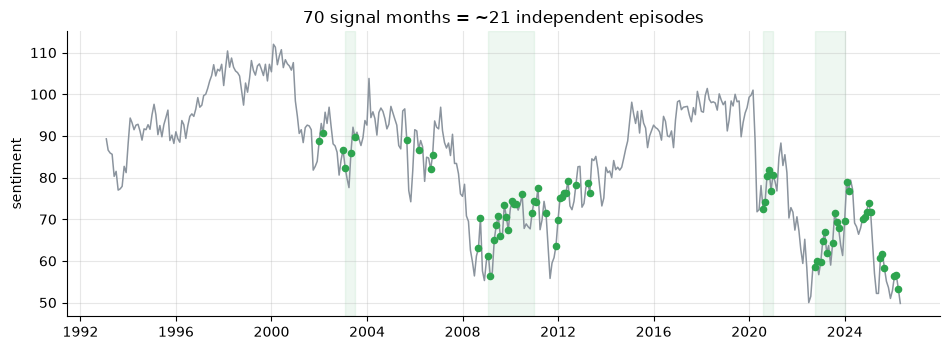

signal months: 70 | episodes (gap>2mo): 21


In [5]:
if HAVE_REAL:
    mask = st.regime_mask(F)['low_rising'].fillna(False)
    fire = F.index[mask]
    fig, ax = plt.subplots(figsize=(9.6, 3.6))
    ax.plot(F.index, F['sent'].values, c=GREY, lw=1.1)
    ax.scatter(fire, F['sent'].reindex(fire).values, s=20, c=GREEN, zorder=3)
    for yr in ('2003','2009','2020','2022'):
        sub = fire[(fire>=f'{yr}-01-01') & (fire<f'{int(yr)+2}-01-01')]
        if len(sub): ax.axvspan(sub.min(), sub.max(), color=GREEN, alpha=.08)
    ax.set_title(f'{int(mask.sum())} signal months = ~{st.n_episodes(F)} independent episodes')
    ax.set_ylabel('sentiment'); plt.tight_layout(); plt.show()
    print('signal months:', int(mask.sum()), '| episodes (gap>2mo):', st.n_episodes(F))
else:
    print(f"{R['h12'][5]} signal months -> ~{R['episodes']} independent episodes")

> 💡 In plain words: **64 months** collapse to **~21 episodes**. With an effective sample of ~20 clustered recoveries, a two-point 12-month excess is well within what chance produces — precisely what the block bootstrap reports. The naive *t*'s denominator uses $k=64$; the honest one knows better.

### 4e · Tradability — the buy-the-bottom overlay

Long SPY only in LOW&RISING months, else cash (1-month lag, 10 bps/switch). Annualised mean and Sharpe vs buy-and-hold; note the exposure.

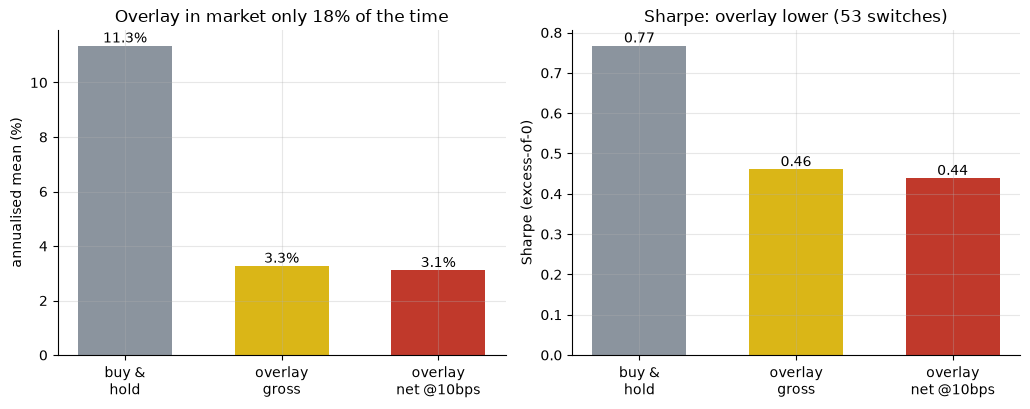

net overlay 3.1%/yr (Sharpe 0.44) vs buy-hold 11.3%/yr (Sharpe 0.77), exposure 18%


In [6]:
if HAVE_REAL:
    o = st.timing_overlay(F, cost_bps=10.0)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    g_m, g_s = o['overlay_gross_mean']*100, o['overlay_gross_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; expo=o['exposure']*100; nsw=o['n_switches']
else:
    bh_m,bh_s = R['overlay'][0],R['overlay'][1]; g_m,g_s=R['overlay'][2],R['overlay'][3]
    n_m,n_s = R['overlay'][4],R['overlay'][5]; nsw=R['overlay'][6]; expo=R['overlay'][7]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold','overlay\ngross','overlay\nnet @10bps']
a1.bar(labels, [bh_m,g_m,n_m], color=[GREY,AMBER,RED], width=.6)
for i,v in enumerate([bh_m,g_m,n_m]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised mean (%)'); a1.set_title(f'Overlay in market only {expo:.0f}% of the time')
a2.bar(labels, [bh_s,g_s,n_s], color=[GREY,AMBER,RED], width=.6)
for i,v in enumerate([bh_s,g_s,n_s]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('Sharpe (excess-of-0)'); a2.set_title(f'Sharpe: overlay lower ({nsw} switches)')
plt.tight_layout(); plt.show()
print(f'net overlay {n_m:.1f}%/yr (Sharpe {n_s:.2f}) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f}), exposure {expo:.0f}%')

> 💡 In plain words: the overlay earns **+3.1%/yr** net (Sharpe 0.44) vs buy-hold **+11.3%** (Sharpe 0.77), in the market only **18%** of the time. Even at zero cost you can't beat full-time ownership by being long a rare subset — the signal is a lean-*in*, not a timing overlay. **`MIRAGE`.**

### 4f · Robustness — the naive *t* is big everywhere, the bootstrap never clears

Vary the percentile threshold and momentum window, and drop the GFC and COVID. The naive *t* stays large across the board; the block-boot *p* never drops below 0.10.

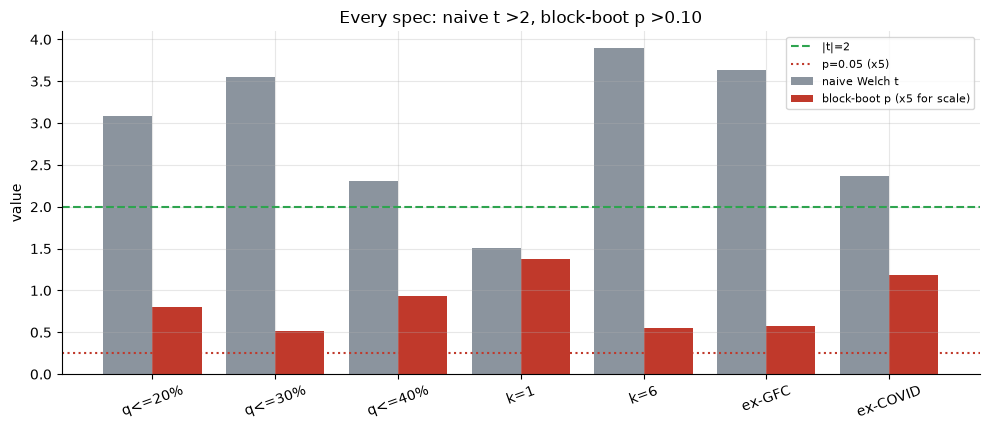

robustness (label, n, naive_t, p_block): [('q<=20%', 47, 3.08, 0.159), ('q<=30%', 64, 3.55, 0.103), ('q<=40%', 89, 2.3, 0.187), ('k=1', 75, 1.51, 0.274), ('k=6', 66, 3.9, 0.111), ('ex-GFC', 64, 3.63, 0.115), ('ex-COVID', 59, 2.37, 0.237)]


In [7]:
if HAVE_REAL:
    rob = []
    for q in (0.20,0.30,0.40):
        s=st.summarize_regime(F,12,low_q=q); rob.append((f'q<={int(q*100)}%', s['n_low_rising'], s['t_low_rising'], s['p_block']))
    for k in (1,6):
        s=st.summarize_regime(F,12,k=k); rob.append((f'k={k}', s['n_low_rising'], s['t_low_rising'], s['p_block']))
    F2=F[(F.index<'2008-07-01')|(F.index>='2009-07-01')]; s=st.summarize_regime(F2,12); rob.append(('ex-GFC', s['n_low_rising'], s['t_low_rising'], s['p_block']))
    F3=F[(F.index<'2020-01-01')|(F.index>='2021-01-01')]; s=st.summarize_regime(F3,12); rob.append(('ex-COVID', s['n_low_rising'], s['t_low_rising'], s['p_block']))
else:
    rob = [(l,n,t,p) for (l,n,_r,t,p) in R['robust']]
labels=[r[0] for r in rob]; tvals=[r[2] for r in rob]; pvals=[r[3] for r in rob]
x=np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10.0, 4.4))
ax.bar(x-.2, tvals, .4, color=GREY, label='naive Welch t')
ax.bar(x+.2, [p*5 for p in pvals], .4, color=RED, label='block-boot p (x5 for scale)')
ax.axhline(2, ls='--', c=GREEN, label='|t|=2'); ax.axhline(0.05*5, ls=':', c=RED, label='p=0.05 (x5)')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20); ax.set_ylabel('value')
ax.set_title('Every spec: naive t >2, block-boot p >0.10'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('robustness (label, n, naive_t, p_block):', [(r[0],r[1],round(r[2],2),round(r[3],3)) for r in rob])

> 💡 In plain words: drop the GFC — naive *t* still **3.63**, *p* = **0.12**. Drop COVID — *t* **2.37**, *p* = **0.24**. It isn't one crash; it's the *clustering* itself, and no threshold or window rescues it. A signal significant only through the statistic that ignores its clustering is the textbook definition of **WEAK**.

### 4g · Faithful-engine control — the bootstrap fires when the edge is real

A deterministic series with a *planted* low-then-rising→forward link over the next 12 months. With `edge=0` both the *t* and the block boot must stay flat; with a large `edge` **both** must light up — proving the block bootstrap is honest, not merely conservative.

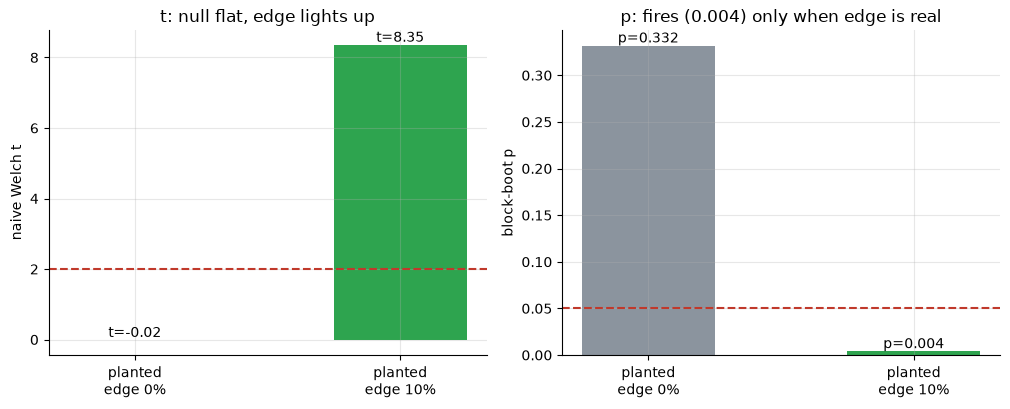

planted 0%: n_lr=29 lr=1.7% base=1.7% t=-0.02 p_block=0.332
planted 10%: n_lr=29 lr=61.2% base=13.0% t=8.35 p_block=0.004


In [8]:
res = []
for edge in (0.0, 0.10):
    syn = data.synthetic(n_months=396, edge=edge, seed=760)
    s = st.summarize_regime(syn['frame'], 12, min_periods=12)
    res.append((edge, s['n_low_rising'], s['low_rising_mean']*100, s['base_mean']*100, s['t_low_rising'], s['p_block']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
labs = [f'planted\nedge {e*100:.0f}%' for e,_,_,_,_,_ in res]
a1.bar(labs, [r[4] for r in res], color=[GREY, GREEN], width=.5)
a1.axhline(2, ls='--', c=RED); 
for i,r in enumerate(res): a1.annotate(f't={r[4]:.2f}',(i,r[4]),ha='center',va='bottom')
a1.set_ylabel('naive Welch t'); a1.set_title('t: null flat, edge lights up')
a2.bar(labs, [r[5] for r in res], color=[GREY, GREEN], width=.5)
a2.axhline(.05, ls='--', c=RED)
for i,r in enumerate(res): a2.annotate(f'p={r[5]:.3f}',(i,r[5]),ha='center',va='bottom')
a2.set_ylabel('block-boot p'); a2.set_title('p: fires (0.004) only when edge is real')
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:.0f}%: n_lr={k} lr={c:.1f}% base={b:.1f}% t={t:.2f} p_block={p:.3f}')

> 💡 In plain words: no planted link → *t* = **-0.02**, block-boot *p* = **0.33** (no false positive). A real planted link → *t* = **8.35** **and** *p* = **0.004**. So the block bootstrap *does* certify a genuine edge — which means the real-tape *p* = 0.10 is a true 'can't certify,' not an over-cautious test. The engine can bank a real bottom-timer; this tape just doesn't carry a certifiable one.

## 5 · The verdict

- **Signal `NONE` (release-day) · `WEAK` (level).** Release day **+6.2 bp** vs **+4.8 bp** (*t* = +0.23), surprise drift the wrong sign. 12m low-and-rising **+6.7pp** excess at naive *t* = **+3.55** but block-boot **p = 0.10**; level alone inert (*t* = -0.25). Literature (Fisher–Statman contrarian effect) + a directionally-right-but-uncertifiable tilt ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`.** Buy-the-bottom overlay **+3.1%/yr** (Sharpe 0.44, exposure 18%) vs buy-hold **+11.3%/yr** (Sharpe 0.77). A lean-in long tilt can't beat full-time ownership.
- **Bottom-timer? `NOT SUPPORTED`.** 64 signal months = ~**21 independent episodes**; significant only via the overlap-blind statistic. The one word that sells it — *timer* — is what the honest inference rejects.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the contrarian tilt is genuine. It still won't deploy. The rule requires sentiment to be cheap **and** already three months into a recovery, so it fires *after* the bottom and only in a few windows a decade — leaving you in cash **82%** of the time while the equity risk premium compounds without you. That structural under-exposure is why the overlay's Sharpe sits **below** passive even at zero cost. And the regime it keys on — a post-crash rebound — is exactly when you'd want *maximum* long exposure, which a long/flat rule structurally cannot deliver. No threshold, window, or lag turns a clustered, lagging, lean-in signal into a market-beating timer.

## 7 · Going further

- **The siblings.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) and [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/): the same hardcoded-snapshot + SPY method on other famous macro 'leading' signals.
- **The cross-section.** Baker–Wurgler (2006) locate the sentiment effect in small, hard-to-arbitrage stocks. Re-run the regime split on a small-cap-value tape — the effect may be sturdier there (and even harder to trade cleanly).
- **Real-time vintages.** Swap the settled `UMCSENT` for the preliminary release (ALFRED) to kill any revision look-ahead; the clustering — the load-bearing problem — survives, because you cannot manufacture independent bottoms by reslicing the same ~20 recoveries.

*The reproducible core is offline and deterministic; the sentiment input is an explicit frozen snapshot. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*